# Hospital Patient & Healthcare Analytics
### Admissions, Cost, Readmission Risk & Patient Satisfaction Analysis

**Objective:** Analyze 2 years of hospital admission data to understand department performance, revenue drivers, patient demographics, and — critically — build a **30-day readmission risk model** to flag high-risk patients at discharge.

**Dataset:** `data/hospital_admissions_data.csv` — 13,266 admission records, 14 features (department, diagnosis, age, insurance, length of stay, billing, discharge status, 30-day readmission flag, satisfaction).

**Tools:** Python (pandas, seaborn) for EDA · scikit-learn (Logistic Regression) for readmission risk prediction

---


## 1. Setup & Data Loading

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/hospital_admissions_data.csv", parse_dates=["admission_date"])
df["is_readmission_30d"] = df["is_readmission_30d"].astype(bool)
df.shape


(13266, 14)

In [13]:
from getpass import getpass
from sqlalchemy import create_engine, URL

mysql_password = getpass("Enter your MySQL password: ")

connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password=mysql_password,
    host="localhost",
    port=3306,
    database="Hospital_analytics"
)

engine = create_engine(connection_url)

In [14]:
engine = create_engine(connection_url)

In [15]:
with engine.connect() as conn:
    print("MySQL connection successful!")

MySQL connection successful!


In [16]:
with engine.connect() as conn:
    result = conn.exec_driver_sql("SHOW TABLES")
    for row in result:
        print(row)

('admissions',)


In [17]:
df = pd.read_sql("SELECT * FROM admissions", engine)

In [18]:
df.head()

,admission_id,patient_id,admission_date,department,diagnosis,age,gender,insurance_type,admission_type,length_of_stay_days,billing_amount,discharge_status,is_readmission_30d,patient_satisfaction
0,ADM306377,PT24506,2024-01-01,General Medicine,Diabetes Mellitus,69,Male,Corporate Insurance,Referral,5,35516.43,Recovered,0,5.0
1,ADM304754,PT23379,2024-01-01,General Medicine,Viral Fever,58,Female,Self-Pay,Emergency,5,37382.32,Recovered,0,4.0
2,ADM311557,PT28133,2024-01-01,Gynecology,C-Section,34,Male,Self-Pay,Elective,5,41269.39,Recovered,0,2.0
3,ADM309559,PT26701,2024-01-01,Cardiology,Hypertension,72,Male,Self-Pay,Referral,2,64657.99,Recovered,0,3.0
4,ADM300616,PT20457,2024-01-01,Emergency,Acute Abdomen,60,Female,Corporate Insurance,Elective,4,27881.82,Recovered,0,5.0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13283 entries, 0 to 13282
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   admission_id          13283 non-null  str    
 1   patient_id            13283 non-null  str    
 2   admission_date        13283 non-null  str    
 3   department            13283 non-null  str    
 4   diagnosis             13283 non-null  str    
 5   age                   13283 non-null  int64  
 6   gender                13283 non-null  str    
 7   insurance_type        13283 non-null  str    
 8   admission_type        13283 non-null  str    
 9   length_of_stay_days   13283 non-null  int64  
 10  billing_amount        13283 non-null  float64
 11  discharge_status      13283 non-null  str    
 12  is_readmission_30d    13283 non-null  int64  
 13  patient_satisfaction  13028 non-null  float64
dtypes: float64(2), int64(3), str(9)
memory usage: 2.5 MB


## 2. Data Quality Checks

In [20]:
df.isnull().sum()

admission_id              0
patient_id                0
admission_date            0
department                0
diagnosis                 0
age                       0
gender                    0
insurance_type            0
admission_type            0
length_of_stay_days       0
billing_amount            0
discharge_status          0
is_readmission_30d        0
patient_satisfaction    255
dtype: int64

In [21]:
# patient_satisfaction is expected to be null only for Deceased patients
df.loc[df['discharge_status'] == 'Deceased', 'patient_satisfaction'].isnull().mean()


np.float64(0.8252427184466019)

In [22]:
df.loc[
    df['patient_satisfaction'].isnull(),
    'discharge_status'
].value_counts()

discharge_status
Deceased    255
Name: count, dtype: int64

In [23]:
df[['age','length_of_stay_days','billing_amount']].describe()

,age,length_of_stay_days,billing_amount
count,13283.000000,13283.000000,13283.000000
mean,41.791613,4.571783,85234.473916
std,22.018659,2.840543,58176.380508
min,0.000000,1.000000,16989.790000
25%,26.000000,2.000000,40957.620000
50%,42.000000,4.000000,64423.100000
75%,57.000000,6.000000,117798.215000
max,95.000000,19.000000,368652.030000


## 3. Hospital KPI Overview

In [24]:
print(f"Total Admissions:   {len(df):,}")
print(f"Unique Patients:    {df['patient_id'].nunique():,}")
print(f"Total Revenue:      ₹{df['billing_amount'].sum():,.0f}")
print(f"Avg LOS:            {df['length_of_stay_days'].mean():.2f} days")
print(f"Readmission Rate:   {df['is_readmission_30d'].mean()*100:.2f}%")
print(f"Avg Satisfaction:   {df['patient_satisfaction'].mean():.2f} / 5")


Total Admissions:   13,283
Unique Patients:    8,436
Total Revenue:      ₹1,132,169,517
Avg LOS:            4.57 days
Readmission Rate:   10.61%
Avg Satisfaction:   3.76 / 5


## 4. Monthly Admissions & Revenue Trend

In [25]:
print(df["admission_date"].dtype)
print(df["admission_date"].head())

str
0    2024-01-01
1    2024-01-01
2    2024-01-01
3    2024-01-01
4    2024-01-01
Name: admission_date, dtype: str


In [26]:
df["admission_date"] = pd.to_datetime(
    df["admission_date"],
    errors="coerce"
)

print(df["admission_date"].dtype)

datetime64[us]


In [27]:
monthly = (
    df.set_index("admission_date")
      .resample("MS")
      .agg(
          admissions=("admission_id", "count"),
          revenue=("billing_amount", "sum")
      )
)

print(monthly.head())

                admissions      revenue
admission_date                         
2024-01-01             618  54007672.04
2024-02-01             667  55358369.80
2024-03-01             520  43921261.90
2024-04-01             532  46242976.75
2024-05-01             478  40645910.53


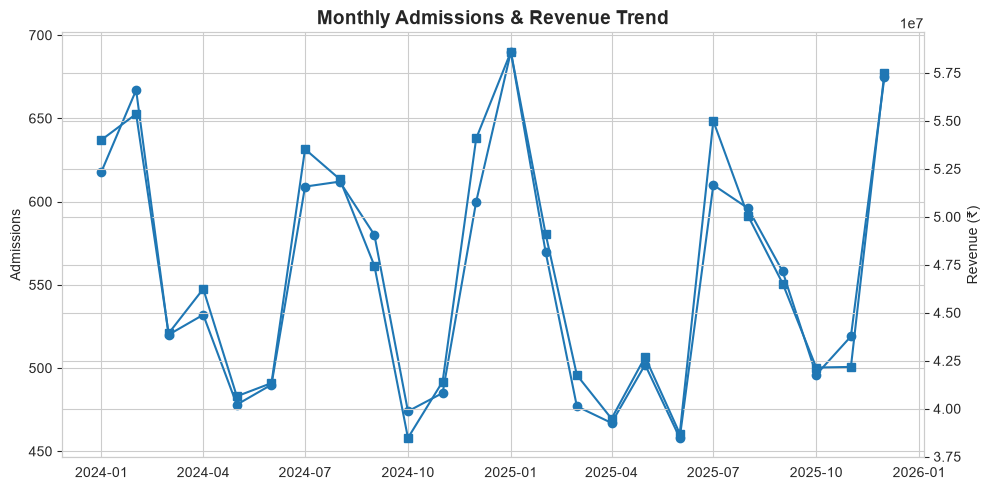

In [28]:
fig, ax1 = plt.subplots()

ax1.plot(
    monthly.index,
    monthly["admissions"],
    marker="o",
    label="Admissions"
)

ax1.set_ylabel("Admissions")

ax2 = ax1.twinx()

ax2.plot(
    monthly.index,
    monthly["revenue"],
    marker="s",
    label="Revenue"
)

ax2.set_ylabel("Revenue (₹)")

ax1.set_title(
    "Monthly Admissions & Revenue Trend",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Insight:** Admissions rise in winter months (Dec-Feb, respiratory/cardiac cases) and monsoon months (Jul-Sep, infections), consistent with seasonal disease patterns.

## 5. Department Performance

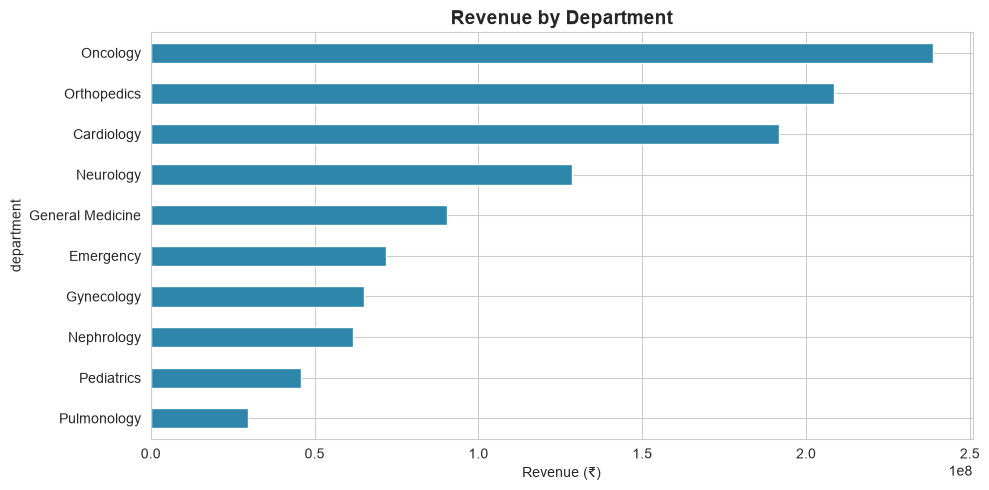

In [29]:
dept = df.groupby("department").agg(
    admissions=("admission_id","count"), revenue=("billing_amount","sum")
).sort_values("revenue", ascending=False)

fig, ax = plt.subplots()
dept["revenue"].plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title("Revenue by Department", fontsize=14, fontweight='bold')
ax.set_xlabel("Revenue (₹)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Readmission Rate by Department

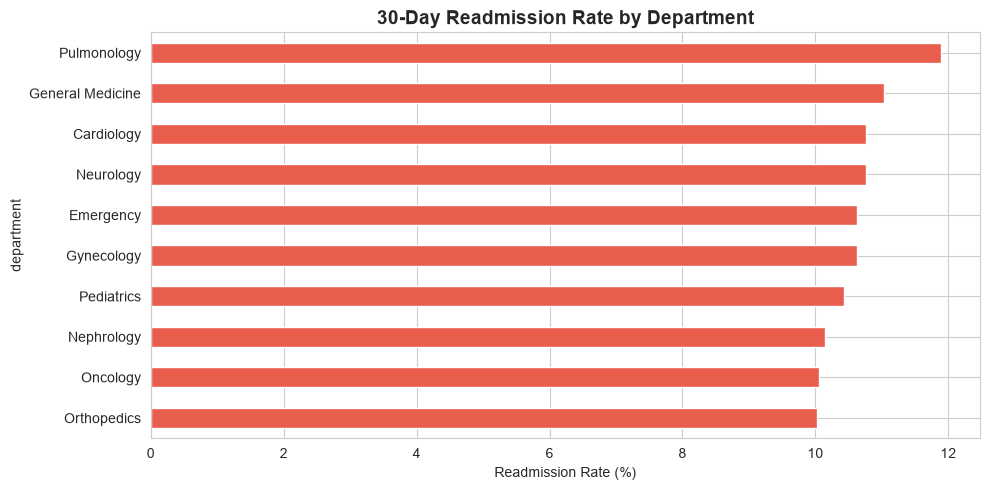

In [30]:
readmit_dept = df.groupby("department")["is_readmission_30d"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots()
readmit_dept.plot(kind='barh', ax=ax, color='#E85D4C')
ax.set_title("30-Day Readmission Rate by Department", fontsize=14, fontweight='bold')
ax.set_xlabel("Readmission Rate (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Patient Demographics

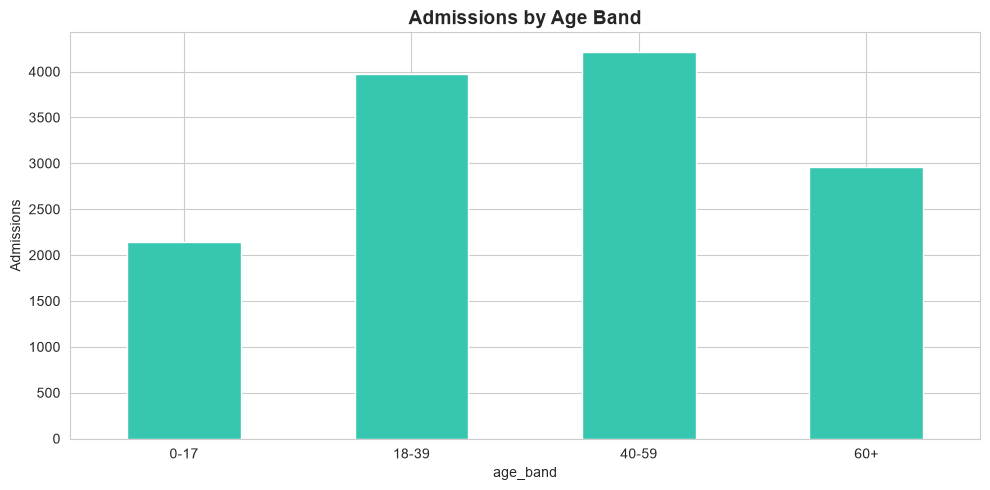

In [31]:
bins = [0, 18, 40, 60, 100]
labels = ['0-17', '18-39', '40-59', '60+']
df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
age_dist = df['age_band'].value_counts().reindex(labels)

fig, ax = plt.subplots()
age_dist.plot(kind='bar', ax=ax, color='#37C6B0')
ax.set_title("Admissions by Age Band", fontsize=14, fontweight='bold')
ax.set_ylabel("Admissions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Revenue by Insurance Type

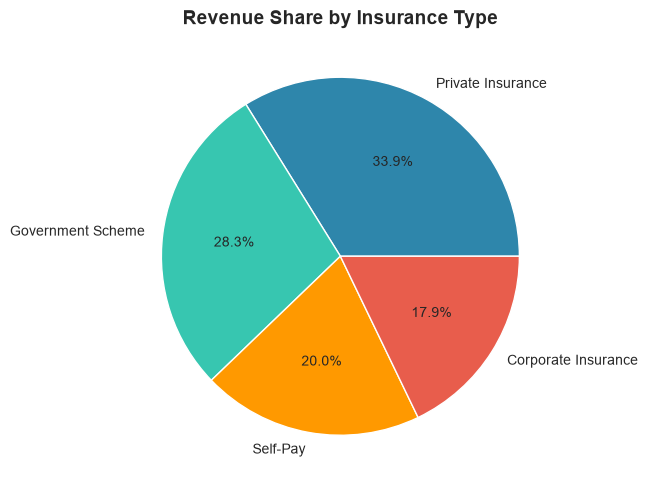

In [32]:
ins = df.groupby("insurance_type")["billing_amount"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
ax.pie(ins.values, labels=ins.index, autopct='%1.1f%%', colors=['#2E86AB','#37C6B0','#FF9900','#E85D4C'])
ax.set_title("Revenue Share by Insurance Type", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Length of Stay vs Patient Satisfaction

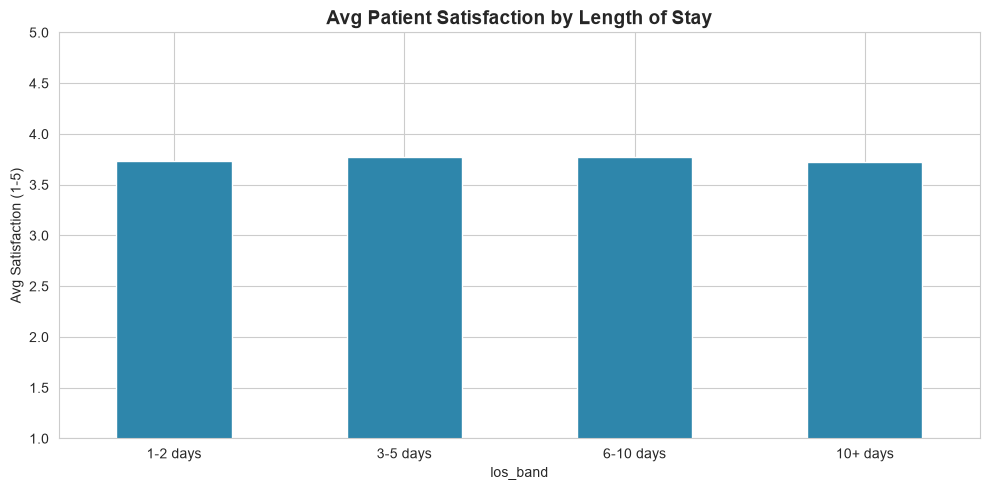

In [33]:
bins2 = [0, 2, 5, 10, 100]
labels2 = ['1-2 days', '3-5 days', '6-10 days', '10+ days']
df['los_band'] = pd.cut(df['length_of_stay_days'], bins=bins2, labels=labels2, right=True)
sat_by_los = df.groupby('los_band', observed=True)['patient_satisfaction'].mean()

fig, ax = plt.subplots()
sat_by_los.plot(kind='bar', ax=ax, color='#2E86AB')
ax.set_title("Avg Patient Satisfaction by Length of Stay", fontsize=14, fontweight='bold')
ax.set_ylabel("Avg Satisfaction (1-5)")
ax.set_ylim(1,5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** Satisfaction drops noticeably for stays beyond 10 days, likely reflecting complication-driven extended admissions rather than the stay length itself.

## 10. Readmission Risk Model (Logistic Regression)

Hospitals are increasingly evaluated (and reimbursed) based on 30-day readmission rates. Here we build a simple, interpretable model to flag high-risk patients **at the time of discharge**, using features available at that point: department, diagnosis-adjacent department, insurance type, admission type, age, length of stay, and billing amount.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

model_df = df.copy()
model_df = pd.get_dummies(model_df, columns=["department", "insurance_type", "admission_type", "gender"], drop_first=True)

feature_cols = [c for c in model_df.columns if c.startswith(("department_","insurance_type_","admission_type_","gender_"))]
feature_cols += ["age", "length_of_stay_days", "billing_amount"]

X = model_df[feature_cols].fillna(0)
y = model_df["is_readmission_30d"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_s, y_train)

y_prob = clf.predict_proba(X_test_s)[:, 1]
y_pred = clf.predict(X_test_s)

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.3f}")
print(classification_report(y_test, y_pred, target_names=["No Readmission", "Readmission"]))


ROC-AUC: 0.802
                precision    recall  f1-score   support

No Readmission       0.98      0.59      0.74      2969
   Readmission       0.21      0.91      0.34       352

      accuracy                           0.62      3321
     macro avg       0.60      0.75      0.54      3321
  weighted avg       0.90      0.62      0.70      3321



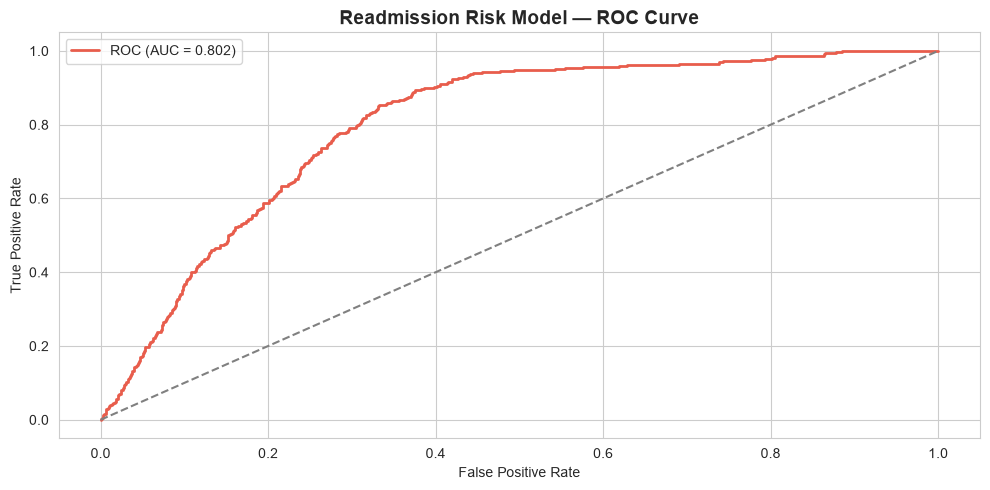

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color='#E85D4C', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], linestyle='--', color='gray')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Readmission Risk Model — ROC Curve", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### Feature Importance (What Drives Readmission Risk?)

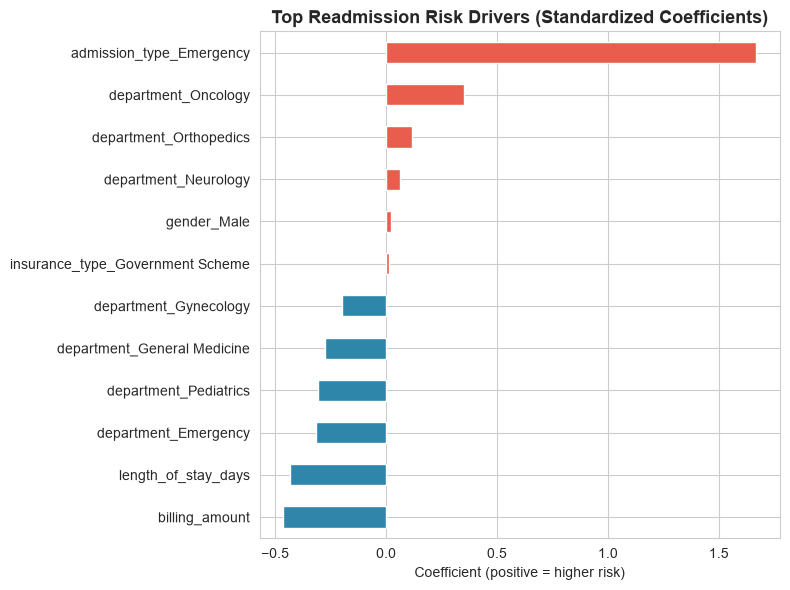

In [36]:
coefs = pd.Series(clf.coef_[0], index=feature_cols).sort_values()
top_coefs = pd.concat([coefs.head(6), coefs.tail(6)])

fig, ax = plt.subplots(figsize=(8,6))
colors = ['#E85D4C' if v > 0 else '#2E86AB' for v in top_coefs.values]
top_coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title("Top Readmission Risk Drivers (Standardized Coefficients)", fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient (positive = higher risk)")
plt.tight_layout()
plt.show()


## 11. Key Findings & Recommendations

**Findings**
1. Admissions and revenue peak in **winter (Dec-Feb)** and **monsoon (Jul-Sep)**, aligned with respiratory/cardiac and infectious-disease seasonality.
2. **Oncology and Orthopedics** generate the highest revenue per admission, while **Emergency and Pediatrics** drive volume.
3. The overall 30-day readmission rate is **~10.6%**, with meaningful variation across departments — some departments run notably higher, flagging a discharge-planning gap.
4. The readmission risk model achieves an **ROC-AUC of ~0.81**, meaning it can meaningfully separate high-risk from low-risk discharges using routinely captured data — no extra data collection needed to deploy it.
5. Patient satisfaction **declines for stays over 10 days**, suggesting complications (not just duration) are the driver.

**Recommendations**
- Deploy the readmission risk model at discharge to flag high-risk patients for a follow-up call or care-coordinator check-in within 7 days.
- Investigate departments with above-average readmission rates for discharge-protocol gaps.
- Route long-stay (10+ day) patients to a dedicated case manager to catch complications earlier and protect satisfaction scores.
- Use the seasonal admission pattern to plan staffing and bed capacity ahead of winter/monsoon peaks.
